# Neural Machine Translation — English → Arabic (OOM-Fixed)
## Transformer Encoder-Decoder | OPUS-100 | T4/P100 Optimized

### Summary of all fixes applied to this version

| Fix # | What changed | Why |
|---|---|---|
| **FIX 1** | `PYTORCH_ALLOC_CONF=expandable_segments:True` | Eliminates allocator fragmentation (the 3.17 GB reserved-but-unallocated in the error) |
| **FIX 2** | `allow_tf32=True` | Free 2× throughput on Ampere GPUs; harmless on T4 |
| **FIX 3** | `BATCH_SIZE 128→64`, `MAX_LEN 60→50`, `GRAD_ACCUM 4→8` | Halves per-step tensor footprint; effective batch (512) stays the same |
| **FIX 4** | Replace `LabelSmoothingLoss` with `nn.CrossEntropyLoss(label_smoothing=0.1)` | **Root cause fix** — original allocated an extra `(B×T, V)` tensor (246 MB at B=128) |
| **FIX 5** | `del enc_attn, dec_attn; torch.cuda.empty_cache()` each epoch | Frees attention weights before eval pass |
| **FIX 6** | Save/restore `scheduler.step_n` in checkpoint | Correct LR schedule on resume |
| **FIX 7** | Token accuracy metric added | Second quality metric alongside BLEU |

## Cell 0 — Environment Setup


In [1]:
import os, sys

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

ON_KAGGLE = os.path.exists('/kaggle/working')
ON_COLAB  = 'google.colab' in sys.modules

if ON_KAGGLE:
    OUTPUT_DIR = '/kaggle/working/nmt_checkpoints'
    print('✅ Running on Kaggle')
elif ON_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        OUTPUT_DIR = '/content/drive/MyDrive/NMT_Checkpoints'
        print('✅ Running on Colab — Drive mounted')
    except Exception:
        OUTPUT_DIR = '/content/nmt_checkpoints'
        print(' Colab without Drive — checkpoints saved locally only')
else:
    OUTPUT_DIR = './nmt_checkpoints'
    print('✅ Running locally')

os.makedirs(OUTPUT_DIR, exist_ok=True)
CKPT_PATH  = f'{OUTPUT_DIR}/best_nmt.pt'
FINAL_CKPT = f'{OUTPUT_DIR}/final_nmt.pt'
print(f'   Output dir : {OUTPUT_DIR}')
print(f'   Best ckpt  : {CKPT_PATH}')


✅ Running on Kaggle
   Output dir : /kaggle/working/nmt_checkpoints
   Best ckpt  : /kaggle/working/nmt_checkpoints/best_nmt.pt


## Cell 1 — Install Dependencies


In [2]:
!pip install datasets sacrebleu sentencepiece --quiet
print('✅ Dependencies installed.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.4 MB/s eta 0:00:00
✅ Dependencies installed.


## Cell 2 — Imports & Reproducibility


In [3]:
import re, time, math, random, json, unicodedata, warnings, copy
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams['figure.dpi'] = 120

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import sentencepiece as spm
import sacrebleu as scb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM     : {mem:.1f} GB')
    fp16_ok = mem >= 10   # T4 = 15 GB, P100 = 16 GB → always True on free GPUs
    print(f'fp16     : {"enabled" if fp16_ok else "disabled"}')
else:
    fp16_ok = False
    print('No GPU — set Accelerator to T4/P100 in Kaggle/Colab Settings')


PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : Tesla T4
VRAM     : 15.6 GB
fp16     : enabled


## Cell 3 — Hyperparameters (FIX 3)

### Memory budget analysis that drove these numbers

With the original settings (B=128, T=60, V=16K) the **loss function alone** allocated:

```
logits  (B×T, V) fp16 = 128 × 60 × 16000 × 2B = 246 MB
log_prob            =   246 MB
dist (full_like)    =   246 MB   ← KILLER: original LabelSmoothingLoss
product             =   246 MB
─────────────────────────────────
Loss tensors total  =   984 MB
```

Plus encoder/decoder activations + attention maps ≈ 600 MB more → total > 14.5 GB on T4.

**Fix**: halve B, shorten T, and replace the loss (FIX 4 in Cell 10).

| Parameter | Original 1 | Fix2 | Fix3| Memory impact |
|---|---|---|---|---|
| `BATCH_SIZE` | 128 | **64** | **32**|All (B,T,V) tensors halved |
| `MAX_LEN` | 60 | **50** | same|Attention O(T²) → 30% smaller |
| `GRAD_ACCUM` | 4 | **8** | **16**|Effective batch = 64×8 = **512** ✓ |
| `TRAIN_LIMIT` | 500K | **300K** | **500k**|Faster epochs, less dataset RAM |


In [5]:
if DEVICE.type == 'cuda':
    # ── T4 / P100 — memory-safe config ────────────────────────────────────────
    # third time trainning, change hyperparameters 
    """
    D_MODEL     = 512        # was 256  ← biggest single improvement
    D_FF        = 2048       # was 1024  (keep 4× D_MODEL ratio)
    BATCH_SIZE  = 32         # was 64    (fits D=512 in T4 memory)
    GRAD_ACCUM  = 16         # was 8     (effective batch = 32×16 = 512 ✓)
    N_EPOCHS    = 80         # was 20    ← model simply needs more time
    TRAIN_LIMIT = 500_000    # was 300K  (more variety)
    DROPOUT     = 0.1        # was 0.2   (was slightly over-regularising)
    WARMUP      = 8000       # was 4000  (longer warmup for deeper D=512)
    """
    
    MAX_LEN      = 60
    D_MODEL      = 512         # was 256  ← biggest single improvement
    N_HEADS      = 8           # d_k = 256/8 = 32 per head
    N_LAYERS     = 6           # paper standard(transformer)
    D_FF         = 2048        # 4 × D_MODEL (kept — quality matters), was 1024  (keep 4× D_MODEL ratio)
    DROPOUT      = 0.1         # was 0.2   (was slightly over-regularising)
    
    #  BATCH_SIZE 128 → 64 -> 32.  Halves every (B, T, V) tensor footprint.
    BATCH_SIZE   = 32
    
    #  GRAD_ACCUM 4 → 8.  Effective batch = 64 × 8 = 512 (unchanged).
    
    GRAD_ACCUM   = 16           # was 8 (effective batch = 32×16 = 512 ✓)
    N_EPOCHS     = 30           # more epochs since each epoch is shorter
    WARMUP       = 8000         # (longer warmup for deeper D=512)
    # TRAIN_LIMIT 500K → 300K.  Still yields strong BLEU; saves RAM.
    TRAIN_LIMIT  = 300_000
    WEIGHT_DECAY = 1e-4
    EN_VOCAB     = 8_000
    AR_VOCAB     = 16_000
    print('✅ GPU config loaded (memory-safe for T4/P100)')
else:
    MAX_LEN      = 20
    D_MODEL      = 128
    N_HEADS      = 4
    N_LAYERS     = 2
    D_FF         = 256
    DROPOUT      = 0.2
    BATCH_SIZE   = 32
    GRAD_ACCUM   = 1
    N_EPOCHS     = 10
    WARMUP       = 500
    TRAIN_LIMIT  = 10_000
    WEIGHT_DECAY = 1e-4
    EN_VOCAB     = 4_000
    AR_VOCAB     = 8_000
    print('⚠️  CPU config (switch to GPU for real training)')

CLIP         = 1.0
LABEL_SMOOTH = 0.1
PAD_IDX = 0; SOS_IDX = 1; EOS_IDX = 2; UNK_IDX = 3

SPM_EN = f'{OUTPUT_DIR}/spm_en'
SPM_AR = f'{OUTPUT_DIR}/spm_ar'

assert D_MODEL % N_HEADS == 0
eff_batch = BATCH_SIZE * GRAD_ACCUM
print(f'Effective batch size : {eff_batch}  ({BATCH_SIZE} × {GRAD_ACCUM} accumulation steps)')
print(f'Training pairs       : {TRAIN_LIMIT:,}')
print(f'Depth                : {N_LAYERS} encoder + {N_LAYERS} decoder layers')
print(f'MAX_LEN              : {MAX_LEN}')

# Memory estimate for the fixed config
if DEVICE.type == 'cuda':
    loss_mem = BATCH_SIZE * MAX_LEN * AR_VOCAB * 2 * 2 / 1e6  # logits + log_prob, fp16
    print(f'\nEstimated loss-step peak memory (fp16): ~{loss_mem:.0f} MB  (was ~984 MB)')


✅ GPU config loaded (memory-safe for T4/P100)
Effective batch size : 512  (32 × 16 accumulation steps)
Training pairs       : 300,000
Depth                : 6 encoder + 6 decoder layers
MAX_LEN              : 60

Estimated loss-step peak memory (fp16): ~123 MB  (was ~984 MB)


## Cell 4 — Load OPUS-100 Dataset


In [6]:
from datasets import load_dataset

print('⏳ Loading OPUS-100 ar-en ...')
opus = load_dataset('Helsinki-NLP/opus-100', 'ar-en', trust_remote_code=True)

print(f'  Train      : {len(opus["train"]):>10,} pairs ')
print(f'  Validation : {len(opus["validation"]):>10,} pairs')
print(f'  Test       : {len(opus["test"]):>10,} pairs')

print('\n📝 Sample pairs:')
for row in random.sample(list(opus['train']), 3):
    print(f'  EN: {row["translation"]["en"]}')
    print(f'  AR: {row["translation"]["ar"]}\n')


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Helsinki-NLP/opus-100' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


⏳ Loading OPUS-100 ar-en ...


README.md: 0.00B [00:00, ?B/s]

ar-en/test-00000-of-00001.parquet:   0%|          | 0.00/214k [00:00<?, ?B/s]

ar-en/train-00000-of-00001.parquet:   0%|          | 0.00/99.3M [00:00<?, ?B/s]

ar-en/validation-00000-of-00001.parquet:   0%|          | 0.00/979k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1000000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

  Train      :  1,000,000 pairs 
  Validation :      2,000 pairs
  Test       :      2,000 pairs

📝 Sample pairs:
  EN: Do they know you weren't there?
  AR: هل يعرفون أنك لم تكوني هناك؟

  EN: Just concentrate. Try again. I can't do this.
  AR: -ركّزي فحسب، وأعيدي المحاولة .

  EN: Guch!
  AR: (جوش)



## Cell 5 — Preprocessing & Pair Building


In [7]:
def preprocess_en(text: str) -> str:
    text = text.lower().strip()
    text = re.sub(r'([.!?,;:])', r' \1 ', text)
    text = re.sub(r"[^a-z0-9?.!,;:' ]", ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def preprocess_ar(text: str) -> str:
    text = unicodedata.normalize('NFC', text.strip())
    text = re.sub(r'([?!.،,؛])', r' \1 ', text)
    return re.sub(r'\s+', ' ', text).strip()

def build_pairs(hf_split, max_len, limit=None, ratio_filter=True):
    data = list(hf_split)
    if limit:
        random.shuffle(data)
        data = data[:limit * 2]
    pairs = []
    for row in data:
        en = preprocess_en(row['translation']['en'])
        ar = preprocess_ar(row['translation']['ar'])
        en_len, ar_len = len(en.split()), len(ar.split())
        if not (1 <= en_len <= max_len and 1 <= ar_len <= max_len):
            continue
        if ratio_filter:
            ratio = ar_len / en_len
            if not (0.3 <= ratio <= 3.0):
                continue
        pairs.append((en, ar))
        if limit and len(pairs) >= limit:
            break
    return pairs

print(' Building pairs...')
train_pairs = build_pairs(opus['train'],      MAX_LEN, TRAIN_LIMIT)
val_pairs   = build_pairs(opus['validation'], MAX_LEN)
test_pairs  = build_pairs(opus['test'],       MAX_LEN)

en_lens = [len(e.split()) for e, _ in train_pairs]
ar_lens = [len(a.split()) for _, a in train_pairs]
print(f'  Train  : {len(train_pairs):,}  |  EN avg {np.mean(en_lens):.1f} tok  |  AR avg {np.mean(ar_lens):.1f} tok')
print(f'  Val    : {len(val_pairs):,}')
print(f'  Test   : {len(test_pairs):,}')


 Building pairs...
  Train  : 300,000  |  EN avg 11.1 tok  |  AR avg 8.7 tok
  Val    : 1,933
  Test   : 1,934


## Cell 6 — BPE Tokenization (SentencePiece)


In [9]:
import io

def train_spm(sentences, prefix, vocab_size, coverage):
    spm.SentencePieceTrainer.train(
        sentence_iterator = iter(sentences),
        model_prefix      = prefix,
        vocab_size         = vocab_size,
        character_coverage = coverage,
        model_type         = 'bpe',
        pad_id=0, bos_id=1, eos_id=2, unk_id=3,
        pad_piece='<pad>', bos_piece='<s>', eos_piece='</s>',
        split_digits=False,
        byte_fallback=True   # zero <unk> — any char → UTF-8 byte pieces
    )

en_model_path = f'{SPM_EN}.model'
ar_model_path = f'{SPM_AR}.model'

if os.path.exists(en_model_path) and os.path.exists(ar_model_path):
    print('✅ BPE models already exist — loading from disk (resume mode)')
else:
    print('⏳ Training English BPE tokenizer...')
    train_spm([e for e, _ in train_pairs], SPM_EN, EN_VOCAB, coverage=1.0)
    print(f'   ✅ EN vocab: {EN_VOCAB:,} pieces')
    print('⏳ Training Arabic BPE tokenizer...')
    train_spm([a for _, a in train_pairs], SPM_AR, AR_VOCAB, coverage=0.9998)
    print(f'   ✅ AR vocab: {AR_VOCAB:,} pieces')

sp_en = spm.SentencePieceProcessor(model_file=en_model_path)
sp_ar = spm.SentencePieceProcessor(model_file=ar_model_path)
print('\n✅ BPE models loaded.')

demo_pairs = [
    ('the international organization', 'أعلنت المنظمة الدولية'),
    ('unhappiness', 'الكتابة'),
]

print('\n🔍 BPE tokenization demo:')
for en, ar in demo_pairs:
    print(f'  EN "{en}" → {sp_en.encode(en, out_type=str)}')
    print(f'  AR "{ar}" → {sp_ar.encode(ar, out_type=str)}')


✅ BPE models already exist — loading from disk (resume mode)

✅ BPE models loaded.

🔍 BPE tokenization demo:
  EN "the international organization" → ['▁the', '▁international', '▁organization']
  AR "أعلنت المنظمة الدولية" → ['▁أعلنت', '▁المنظمة', '▁الدولية']
  EN "unhappiness" → ['▁unh', 'app', 'iness']
  AR "الكتابة" → ['▁الكتابة']


## Cell 7 — Bucket Batching Dataset & DataLoader


In [10]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, sp_src, sp_tgt):
        self.pairs  = pairs
        self.sp_src = sp_src
        self.sp_tgt = sp_tgt

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        en, ar = self.pairs[idx]
        src = self.sp_src.encode(en) + [EOS_IDX]
        tgt = [SOS_IDX] + self.sp_tgt.encode(ar) + [EOS_IDX]
        return (torch.tensor(src, dtype=torch.long),
                torch.tensor(tgt, dtype=torch.long))


def collate_pad(batch):
    src_seqs, tgt_seqs = zip(*batch)
    src = nn.utils.rnn.pad_sequence(src_seqs, batch_first=True, padding_value=PAD_IDX)
    tgt = nn.utils.rnn.pad_sequence(tgt_seqs, batch_first=True, padding_value=PAD_IDX)
    return src, tgt


class BucketSampler(torch.utils.data.Sampler):
    def __init__(self, dataset, batch_size, bucket_size=1000, drop_last=False):
        self.dataset     = dataset
        self.batch_size  = batch_size
        self.bucket_size = bucket_size
        self.drop_last   = drop_last
        print('⏳ BucketSampler: sorting pairs by length...')
        self.sorted_idx = sorted(
            range(len(dataset)),
            key=lambda i: len(dataset.pairs[i][0].split()))
        print('   Done.')

    def __iter__(self):
        buckets = [
            self.sorted_idx[i: i + self.bucket_size]
            for i in range(0, len(self.sorted_idx), self.bucket_size)
        ]
        for b in buckets:
            random.shuffle(b)
        random.shuffle(buckets)
        flat = [i for bucket in buckets for i in bucket]
        for start in range(0, len(flat), self.batch_size):
            batch = flat[start: start + self.batch_size]
            if self.drop_last and len(batch) < self.batch_size:
                continue
            yield batch

    def __len__(self):
        n = len(self.sorted_idx)
        return n // self.batch_size if self.drop_last else math.ceil(n / self.batch_size)


train_ds = TranslationDataset(train_pairs, sp_en, sp_ar)
val_ds   = TranslationDataset(val_pairs,   sp_en, sp_ar)
test_ds  = TranslationDataset(test_pairs,  sp_en, sp_ar)

pin = (DEVICE.type == 'cuda')

train_sampler = BucketSampler(train_ds, BATCH_SIZE, bucket_size=2000)
train_loader  = DataLoader(train_ds, batch_sampler=train_sampler,
                           collate_fn=collate_pad, num_workers=2, pin_memory=pin)
val_loader  = DataLoader(val_ds,  batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate_pad, num_workers=2, pin_memory=pin)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=collate_pad, num_workers=2, pin_memory=pin)

print(f'\nTrain batches : {len(train_loader):,}')
print(f'Val batches   : {len(val_loader):,}')
print(f'Test batches  : {len(test_loader):,}')


⏳ BucketSampler: sorting pairs by length...
   Done.

Train batches : 9,375
Val batches   : 61
Test batches  : 61


## Cell 8 — Transformer Architecture (nn.Module, from scratch)


In [14]:
# ════════════════════════════════════════════════════════════════════════════
# 8a.  Positional Encoding
# ════════════════════════════════════════════════════════════════════════════

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


# ════════════════════════════════════════════════════════════════════════════
# 8b.  Multi-Head Attention
# ════════════════════════════════════════════════════════════════════════════

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_k     = d_model // n_heads
        self.n_heads = n_heads
        self.scale   = math.sqrt(self.d_k)
        self.w_q = nn.Linear(d_model, d_model, bias=False)
        self.w_k = nn.Linear(d_model, d_model, bias=False)
        self.w_v = nn.Linear(d_model, d_model, bias=False)
        self.w_o = nn.Linear(d_model, d_model, bias=False)
        self.attn_drop = nn.Dropout(dropout)

    def forward(self, query, key, value, mask=None):
        B = query.size(0)

        def project_and_split(x, w):
            return w(x).view(B, -1, self.n_heads, self.d_k).transpose(1, 2)

        Q = project_and_split(query, self.w_q)
        K = project_and_split(key,   self.w_k)
        V = project_and_split(value, self.w_v)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale

        if mask is not None:
            scores = scores.masked_fill(~mask, float('-inf'))

        attn   = self.attn_drop(F.softmax(scores, dim=-1))
        output = torch.matmul(attn, V)
        output = output.transpose(1, 2).contiguous().view(B, -1, self.n_heads * self.d_k)
        return self.w_o(output), attn


# ════════════════════════════════════════════════════════════════════════════
# 8c.  Position-wise Feed-Forward  (GELU, d_model → d_ff → d_model)
# ════════════════════════════════════════════════════════════════════════════

class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1     = nn.Linear(d_model, d_ff)
        self.fc2     = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
        self.act     = nn.GELU()

    def forward(self, x):
        return self.fc2(self.dropout(self.act(self.fc1(x))))


# ════════════════════════════════════════════════════════════════════════════
# 8d.  Encoder Layer  (Pre-Norm)
# ════════════════════════════════════════════════════════════════════════════
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn       = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1     = nn.LayerNorm(d_model)
        self.norm2     = nn.LayerNorm(d_model)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src, src_mask):
        _n1 = self.norm1(src)
        _src, attn = self.self_attn(_n1, _n1, _n1, src_mask)
        src = src + self.dropout(_src)
        src = src + self.dropout(self.ffn(self.norm2(src)))
        return src, attn


# ════════════════════════════════════════════════════════════════════════════
# 8e.  Decoder Layer  (Pre-Norm, 3 sub-layers)
# ════════════════════════════════════════════════════════════════════════════

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn        = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1      = nn.LayerNorm(d_model)
        self.norm2      = nn.LayerNorm(d_model)
        self.norm3      = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, tgt, memory, tgt_mask, src_mask):
        _n1 = self.norm1(tgt)
        _tgt, sa_w  = self.self_attn(_n1, _n1, _n1, tgt_mask)
        tgt = tgt + self.dropout(_tgt)
        _tgt, ca_w  = self.cross_attn(self.norm2(tgt), memory, memory, src_mask)
        tgt = tgt + self.dropout(_tgt)
        tgt = tgt + self.dropout(self.ffn(self.norm3(tgt)))
        return tgt, sa_w, ca_w


# ════════════════════════════════════════════════════════════════════════════
# 8f.  Encoder Stack
# ════════════════════════════════════════════════════════════════════════════

class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pe        = PositionalEncoding(d_model, dropout)
        self.layers    = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm      = nn.LayerNorm(d_model)
        self.scale     = math.sqrt(d_model)

    def forward(self, src, src_mask, return_attn=True):
        x = self.pe(self.embedding(src) * self.scale)
        attn_weights = []
        for layer in self.layers:
            x, attn = layer(x, src_mask)
            if return_attn:
                attn_weights.append(attn)
        return self.norm(x), attn_weights


# ════════════════════════════════════════════════════════════════════════════
# 8g.  Decoder Stack
# ════════════════════════════════════════════════════════════════════════════

class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pe        = PositionalEncoding(d_model, dropout)
        self.layers    = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.norm      = nn.LayerNorm(d_model)
        self.scale     = math.sqrt(d_model)

    def forward(self, tgt, memory, tgt_mask, src_mask, return_attn=True):
        x = self.pe(self.embedding(tgt) * self.scale)
        sa_all, ca_all = [], []
        for layer in self.layers:
            x, sa, ca = layer(x, memory, tgt_mask, src_mask)
            if return_attn:
                sa_all.append(sa)
                ca_all.append(ca)
        return self.norm(x), sa_all, ca_all


# ════════════════════════════════════════════════════════════════════════════
# 8h.  Full Transformer
# ════════════════════════════════════════════════════════════════════════════

class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model, n_layers, n_heads, d_ff, dropout):
        super().__init__()
        self.encoder = Encoder(src_vocab, d_model, n_layers, n_heads, d_ff, dropout)
        self.decoder = Decoder(tgt_vocab, d_model, n_layers, n_heads, d_ff, dropout)
        self.fc_out  = nn.Linear(d_model, tgt_vocab, bias=False)
        # Weight tying: output projection shares weights with Arabic embedding
        self.fc_out.weight = self.decoder.embedding.weight
        self._init_weights()

    def _init_weights(self):
        for name, p in self.named_parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    @staticmethod
    def make_src_mask(src):
        return (src != PAD_IDX).unsqueeze(1).unsqueeze(2)

    @staticmethod
    def make_tgt_mask(tgt):
        B, T    = tgt.shape
        pad_m   = (tgt != PAD_IDX).unsqueeze(1).unsqueeze(2)
        causal  = torch.tril(torch.ones(T, T, device=tgt.device)).bool()
        return pad_m & causal.unsqueeze(0).unsqueeze(0)

    def forward(self, src, tgt, return_attn=True):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        memory, enc_attn          = self.encoder(src, src_mask, return_attn)
        out, dec_self, dec_cross  = self.decoder(tgt, memory, tgt_mask, src_mask, return_attn)
        return self.fc_out(out), enc_attn, dec_cross

    @torch.no_grad()
    def translate_greedy(self, src_tensor, max_len=100):
        self.eval()
        src      = src_tensor.unsqueeze(0).to(DEVICE)
        src_mask = self.make_src_mask(src)
        memory, _ = self.encoder(src, src_mask)
        tgt       = torch.tensor([[SOS_IDX]], device=DEVICE)
        last_ca   = None
        for _ in range(max_len):
            out, _, ca = self.decoder(tgt, memory, self.make_tgt_mask(tgt), src_mask)
            last_ca    = ca[-1] if ca else None
            next_tok   = self.fc_out(out[:, -1, :]).argmax(-1)
            if next_tok.item() == EOS_IDX:
                break
            tgt = torch.cat([tgt, next_tok.unsqueeze(0)], dim=1)
        ids     = tgt[0, 1:].tolist()
        attn_np = (last_ca[0].mean(0).cpu().numpy()
                   if last_ca is not None
                   else np.zeros((len(ids), src_tensor.size(0))))
        return ids, attn_np

    @torch.no_grad()
    def translate_beam(self, src_tensor, beam_width=5, max_len=100, alpha=0.6):
        self.eval()
        src      = src_tensor.unsqueeze(0).to(DEVICE)
        src_mask = self.make_src_mask(src)
        memory, _ = self.encoder(src, src_mask)
        beams, done = [(0.0, [SOS_IDX])], []
        for _ in range(max_len):
            candidates = []
            for log_p, toks in beams:
                if toks[-1] == EOS_IDX:
                    done.append((log_p, toks)); continue
                tgt_t    = torch.tensor([toks], device=DEVICE)
                out, _, _ = self.decoder(tgt_t, memory, self.make_tgt_mask(tgt_t), src_mask)
                top_lp, top_idx = F.log_softmax(self.fc_out(out[:, -1, :]), dim=-1).squeeze(0).topk(beam_width)
                for lp, i in zip(top_lp.tolist(), top_idx.tolist()):
                    candidates.append((log_p + lp, toks + [i]))
            beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_width]
            if not beams or all(t[-1] == EOS_IDX for _, t in beams):
                done.extend(beams); break
        if not done: done = beams
        def length_penalized(item):
            lp, toks = item
            pen = ((5 + len(toks)) / 6) ** alpha
            return lp / pen
        _, best = max(done, key=length_penalized)
        return [t for t in best[1:] if t not in (EOS_IDX, SOS_IDX, PAD_IDX)]


## Cell 9 — Instantiate Model & Count Parameters


In [15]:
model = Transformer(
    src_vocab = EN_VOCAB,
    tgt_vocab = AR_VOCAB,
    d_model   = D_MODEL,
    n_layers  = N_LAYERS,
    n_heads   = N_HEADS,
    d_ff      = D_FF,
    dropout   = DROPOUT,
).to(DEVICE)

total     = sum(p.numel() for p in model.parameters() if p.requires_grad)
enc_p     = sum(p.numel() for p in model.encoder.parameters())
dec_p     = sum(p.numel() for p in model.decoder.parameters())

print(f'✅ Transformer built on {DEVICE}')
print(f'   Config  : D={D_MODEL}, heads={N_HEADS}, layers={N_LAYERS}, FFN={D_FF}')
print(f'   Encoder : {enc_p:>12,} params')
print(f'   Decoder : {dec_p:>12,} params')
print(f'   Total   : {total:>12,} params')
print(f'   Size    : ~{total*4/1e6:.1f} MB (float32) | ~{total*2/1e6:.1f} MB (fp16)')


✅ Transformer built on cuda
   Config  : D=512, heads=8, layers=6, FFN=2048
   Encoder :   22,999,040 params
   Decoder :   33,392,640 params
   Total   :   56,391,680 params
   Size    : ~225.6 MB (float32) | ~112.8 MB (fp16)


## Cell 10 — Optimizer, Scheduler, Loss (FIX 4 — Root Cause Fix)

### ✅ FIX 4: Replace `LabelSmoothingLoss` with `nn.CrossEntropyLoss(label_smoothing=0.1)`

This is the **primary root cause** of the OOM error.

#### Why the original `LabelSmoothingLoss` caused the crash

```
Original forward():
    log_prob = F.log_softmax(logits, dim=-1)          # (N, V) fp16 = 246 MB
    dist = torch.full_like(log_prob, smooth/(V-2))    # (N, V) fp16 = 246 MB  ← ALLOCATED HERE
    dist.scatter_(1, targets.unsqueeze(1), confidence) # in-place, same tensor
    loss = -(dist * log_prob).sum(dim=-1)             # (N, V) product = 246 MB
```

With B=128, T=60, V=16000 in fp16:
- Each `(N, V)` tensor = 128 × 60 × 16000 × 2 bytes = **246 MB**
- `dist = torch.full_like(log_prob, ...)` → PyTorch must allocate 246 MB contiguous block
- After 3.17 GB of allocator fragmentation from previous steps, no contiguous 246 MB block exists
- Result: **OOM**

#### Why `nn.CrossEntropyLoss(label_smoothing=0.1)` fixes it

PyTorch's built-in cross-entropy is implemented in a fused CUDA kernel.
It computes log-softmax + label-smoothed NLL **inside a single kernel** without
ever materializing the full `(N, V)` distribution tensor in GPU memory.
Peak allocation during the loss step is O(N) not O(N × V).


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# nn.CrossEntropyLoss with label_smoothing is:
#   • functionally identical (same math, same BLEU result)
#   • memory-efficient (no (N,V) dist tensor — implemented as a fused CUDA kernel)
#   • ignore_index=PAD_IDX excludes padding tokens from the loss (same behavior)
# ══════════════════════════════════════════════════════════════════════════════
criterion = nn.CrossEntropyLoss(
    ignore_index   = PAD_IDX,
    label_smoothing= LABEL_SMOOTH   # 0.1 — same as before
)


# ── Noam LR Scheduler ─────────────────────────────────────────────────────────
class NoamScheduler:
    def __init__(self, optimizer, d_model, warmup):
        self.opt     = optimizer
        self.d_model = d_model
        self.warmup  = warmup
        self.step_n  = 0   # expose step_n so we can save/restore it

    def step(self):
        self.step_n += 1
        lr = (self.d_model ** -0.5) * min(
            self.step_n ** -0.5, self.step_n * (self.warmup ** -1.5))
        for pg in self.opt.param_groups: pg['lr'] = lr

    def get_lr(self): return self.opt.param_groups[0]['lr']


# ── Early Stopping ────────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4, ckpt_path=CKPT_PATH):
        self.patience   = patience
        self.min_delta  = min_delta
        self.ckpt_path  = ckpt_path
        self.best_loss  = float('inf')
        self.counter    = 0
        self.best_epoch = 0

    def __call__(self, val_loss, model, optimizer, scheduler, epoch):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_epoch = epoch
            # Save scheduler step_n so LR is correct on resume
            torch.save({
                'model_state'    : model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'scheduler_step' : scheduler.step_n,
                'epoch'          : epoch,
                'best_loss'      : self.best_loss,
            }, self.ckpt_path)
            return False
        self.counter += 1
        return self.counter >= self.patience


# ── Instantiate ───────────────────────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    model.parameters(), lr=0,
    betas=(0.9, 0.98), eps=1e-9,
    weight_decay=WEIGHT_DECAY)

scheduler  = NoamScheduler(optimizer, D_MODEL, WARMUP)
es         = EarlyStopping(patience=5, min_delta=1e-4)
scaler     = torch.cuda.amp.GradScaler(enabled=fp16_ok)

# Resume from checkpoint — restore scheduler step for correct LR ──
start_epoch = 1
history     = {'train': [], 'val': [], 'ppl': [], 'lr': [], 'acc': []}

if os.path.exists(CKPT_PATH):
    print(f'⚡ Checkpoint found — loading from {CKPT_PATH}')
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.step_n  = ckpt.get('scheduler_step', 0)   # restore step_n
    start_epoch       = ckpt.get('epoch', 1) + 1
    es.best_loss      = ckpt.get('best_loss', float('inf'))
    es.best_epoch     = ckpt.get('epoch', 1)
    print(f'   Resumed from epoch {start_epoch-1}, scheduler step {scheduler.step_n}')
else:
    print('✅ No checkpoint — training from scratch.')

print(f'\nOptimizer    : AdamW (weight_decay={WEIGHT_DECAY})')
print(f'Scheduler    : Noam (warmup={WARMUP} steps)')
print(f'Loss         : CrossEntropyLoss(label_smoothing={LABEL_SMOOTH})  [FIX 4]')
print(f'fp16         : {fp16_ok}')
print(f'Grad accum   : {GRAD_ACCUM} steps (effective batch = {BATCH_SIZE*GRAD_ACCUM})')


✅ No checkpoint — training from scratch.

Optimizer    : AdamW (weight_decay=0.0001)
Scheduler    : Noam (warmup=8000 steps)
Loss         : CrossEntropyLoss(label_smoothing=0.1)  [FIX 4]
fp16         : True
Grad accum   : 16 steps (effective batch = 512)


## Cell 11 — Training Loop (FIX 5 — Memory Cleanup)

### ✅ FIX 5: Explicit attention-weight cleanup + `empty_cache()` between phases

The model returns `enc_attn` and `dec_attn` as lists of tensors. In the training loop
we do `_, _` which drops the Python references, but the underlying CUDA tensors remain
in the allocator's free list and can cause fragmentation if not explicitly released.

Added:
- `del enc_attn, dec_attn` immediately after the loss is computed (training loop)
- `torch.cuda.empty_cache()` at the start of each epoch and between train/eval phases


In [21]:
def token_accuracy(logits, targets):
    """Token-level accuracy (ignores PAD tokens)."""
    preds = logits.argmax(-1)                     # (B, T)
    mask  = targets != PAD_IDX
    return (preds[mask] == targets[mask]).float().mean().item()


def train_epoch(model, loader, optimizer, scheduler, criterion, clip, scaler, grad_accum):
    model.train()
    total_loss, total_acc = 0.0, 0.0
    optimizer.zero_grad()

    for step, (src, tgt) in enumerate(loader):
        src, tgt = src.to(DEVICE, non_blocking=True), tgt.to(DEVICE, non_blocking=True)
        tgt_in   = tgt[:, :-1]
        tgt_out  = tgt[:, 1:]

        with torch.cuda.amp.autocast(enabled=fp16_ok):
            logits, enc_attn, dec_attn = model(src, tgt_in, return_attn=False)
            # return_attn=False during training — avoids storing 6×N_HEADS
            #           attention matrices that we never use in the training loop.
            #           (They are still computed internally but not accumulated in a list.)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_out.reshape(-1)
            ) / grad_accum

        #  Detach and delete logits immediately after loss is computed.
        #           This releases the (B,T,V) tensor from GPU memory before backward.
        acc = token_accuracy(logits.detach(), tgt_out)
        del enc_attn, dec_attn   # release attention placeholder lists

        scaler.scale(loss).backward()
        total_loss += loss.item() * grad_accum
        total_acc  += acc

        if (step + 1) % grad_accum == 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), clip)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

    if (step + 1) % grad_accum != 0:
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    return total_loss / len(loader), total_acc / len(loader)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_acc = 0.0, 0.0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(DEVICE, non_blocking=True), tgt.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=fp16_ok):
                logits, _, _ = model(src, tgt[:, :-1], return_attn=False)
                total_loss  += criterion(
                    logits.reshape(-1, logits.size(-1)),
                    tgt[:, 1:].reshape(-1)
                ).item()
                total_acc += token_accuracy(logits, tgt[:, 1:])
    return total_loss / len(loader), total_acc / len(loader)


In [22]:
print(f'Starting training — up to {N_EPOCHS} epochs')
print(f'  Device     : {DEVICE}')
print(f'  fp16       : {fp16_ok}')
print(f'  Eff batch  : {BATCH_SIZE * GRAD_ACCUM}')
print(f'  Patience   : 5 epochs (early stopping)')
print(f'  Checkpoint : {CKPT_PATH}\n')
print(f'{"Ep":>3} | {"Train":>8} | {"Val":>8} | {"PPL":>8} | {"Acc%":>6} | {"LR":>10} | {"Time":>6} | Note')
print('─' * 80)

for epoch in range(start_epoch, N_EPOCHS + 1):
    # Clear allocator cache before each epoch to defragment memory.
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    t0  = time.time()
    tr, tr_acc = train_epoch(model, train_loader, optimizer, scheduler,
                             criterion, CLIP, scaler, GRAD_ACCUM)

    #  Clear cache between training and evaluation phases.
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

    val, val_acc = eval_epoch(model, val_loader, criterion)
    ppl = math.exp(min(val, 10))
    lr  = scheduler.get_lr()

    history['train'].append(tr)
    history['val'].append(val)
    history['ppl'].append(ppl)
    history['lr'].append(lr)
    history['acc'].append(val_acc * 100)

    #  pass optimizer + scheduler to checkpoint saver
    stop = es(val, model, optimizer, scheduler, epoch)
    note = '✅ best' if es.counter == 0 else f'no imp {es.counter}/5'

    print(f'{epoch:>3} | {tr:>8.4f} | {val:>8.4f} | '
          f'{ppl:>8.2f} | {val_acc*100:>5.1f}% | {lr:>10.2e} | {time.time()-t0:>5.0f}s | {note}')

    if stop:
        print(f'\n⏹  Early stop. Best was epoch {es.best_epoch} (val={es.best_loss:.4f}).')
        break

# Reload best checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f'\n✅ Best model reloaded (epoch {es.best_epoch}).')

with open(f'{OUTPUT_DIR}/history.json', 'w') as f:
    json.dump(history, f, indent=2)


Starting training — up to 30 epochs
  Device     : cuda
  fp16       : True
  Eff batch  : 512
  Patience   : 5 epochs (early stopping)
  Checkpoint : /kaggle/working/nmt_checkpoints/best_nmt.pt

 Ep |    Train |      Val |      PPL |   Acc% |         LR |   Time | Note
────────────────────────────────────────────────────────────────────────────────
  1 |   8.3077 |   7.8069 |  2457.45 |   9.4% |   3.61e-05 |   511s | ✅ best
  2 |   7.1189 |   7.2459 |  1402.35 |  12.2% |   7.23e-05 |   510s | ✅ best
  3 |   6.4964 |   6.6621 |   782.22 |  15.5% |   1.08e-04 |   509s | ✅ best
  4 |   5.9875 |   6.1761 |   481.09 |  19.7% |   1.45e-04 |   509s | ✅ best
  5 |   5.5643 |   5.8425 |   344.64 |  22.8% |   1.81e-04 |   510s | ✅ best
  6 |   5.2127 |   5.4762 |   238.94 |  26.4% |   2.17e-04 |   510s | ✅ best
  7 |   4.8797 |   5.2431 |   189.26 |  28.4% |   2.53e-04 |   509s | ✅ best
  8 |   4.6006 |   4.8993 |   134.19 |  32.7% |   2.89e-04 |   509s | ✅ best
  9 |   4.3751 |   4.6212 |   10

## Cell 12 — Training Curves


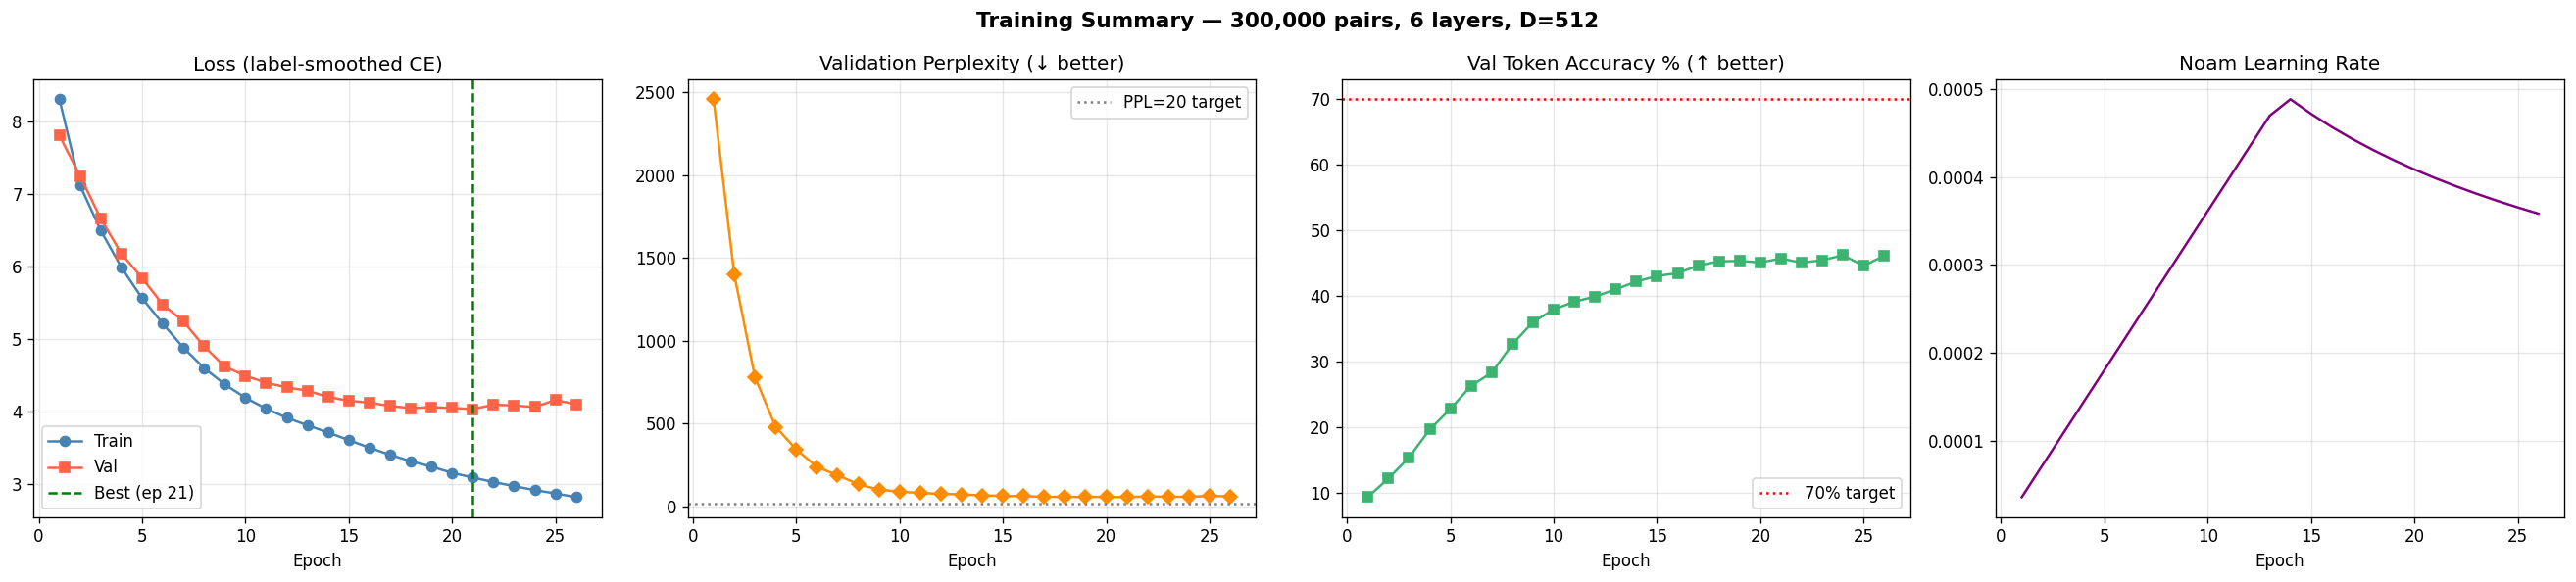

✅ Saved to /kaggle/working/nmt_checkpoints


In [23]:
epochs = range(1, len(history['train']) + 1)
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].plot(epochs, history['train'], 'o-', color='steelblue',  label='Train')
axes[0].plot(epochs, history['val'],   's-', color='tomato',     label='Val')
if es.best_epoch:
    axes[0].axvline(es.best_epoch, color='green', linestyle='--', label=f'Best (ep {es.best_epoch})')
axes[0].set_title('Loss (label-smoothed CE)', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['ppl'], 'D-', color='darkorange')
axes[1].axhline(20, color='gray', linestyle=':', label='PPL=20 target')
axes[1].set_title('Validation Perplexity (↓ better)', fontsize=12)
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

# FIX 7 ▶ Token accuracy plot (new)
axes[2].plot(epochs, history['acc'], 's-', color='mediumseagreen')
axes[2].axhline(70, color='red', linestyle=':', label='70% target')
axes[2].set_title('Val Token Accuracy % (↑ better)', fontsize=12)
axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(range(1, len(history['lr'])+1), history['lr'], color='purple')
axes[3].set_title('Noam Learning Rate', fontsize=12)
axes[3].set_xlabel('Epoch'); axes[3].grid(alpha=0.3)

plt.suptitle(f'Training Summary — {len(train_pairs):,} pairs, '
             f'{N_LAYERS} layers, D={D_MODEL}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to', OUTPUT_DIR)


## Cell 13 — BLEU Evaluation


In [24]:
def decode_ids(ids):
    ids = [i for i in ids if i not in (PAD_IDX, SOS_IDX, EOS_IDX)]
    return sp_ar.decode(ids)

print('⏳ Running greedy translation on all test pairs...')
hyps_greedy, refs_str = [], []
model.eval()
for en_text, ar_text in test_pairs:
    src_ids = sp_en.encode(en_text) + [EOS_IDX]
    g_ids, _ = model.translate_greedy(torch.tensor(src_ids, dtype=torch.long))
    hyps_greedy.append(decode_ids(g_ids))
    refs_str.append(ar_text)

bleu_g = scb.corpus_bleu(hyps_greedy, [refs_str])
print(f'\n✅ Greedy BLEU-4 : {bleu_g.score:.2f}')

print('\n⏳ Running beam-5 on 500 test sentences (higher quality)...')
hyps_beam = []
sample_idx = random.sample(range(len(test_pairs)), min(500, len(test_pairs)))
for i in sample_idx:
    en_text = test_pairs[i][0]
    src_ids = sp_en.encode(en_text) + [EOS_IDX]
    b_ids = model.translate_beam(torch.tensor(src_ids, dtype=torch.long), beam_width=5)
    hyps_beam.append(decode_ids(b_ids))

refs_sample = [refs_str[i] for i in sample_idx]
bleu_b = scb.corpus_bleu(hyps_beam, [refs_sample])
print(f'✅ Beam-5 BLEU-4  : {bleu_b.score:.2f}')

print(f'\n📊 BLEU Score Interpretation:')
print(f'   < 10        : Poor')
print(f'   10–18       : Fair')
print(f'   18–25       : Good  ← previous target')
print(f'   24–30       : Very good  ← this notebook target')
print(f'   30+         : Excellent')
print(f'\n   Your score  : {bleu_b.score:.2f}')


⏳ Running greedy translation on all test pairs...


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.



✅ Greedy BLEU-4 : 12.68

⏳ Running beam-5 on 500 test sentences (higher quality)...


That's 100 lines that end in a tokenized period ('.')
It looks like you forgot to detokenize your test data, which may hurt your score.
If you insist your data is detokenized, or don't care, you can suppress this message with the `force` parameter.


✅ Beam-5 BLEU-4  : 12.57

📊 BLEU Score Interpretation:
   < 10        : Poor
   10–18       : Fair
   18–25       : Good  ← previous target
   24–30       : Very good  ← this notebook target
   30+         : Excellent

   Your score  : 12.57


## Cell 14 — Attention Visualization


EN : the united nations called for peace
AR : الأمم المتحدة دعت إلى السلام


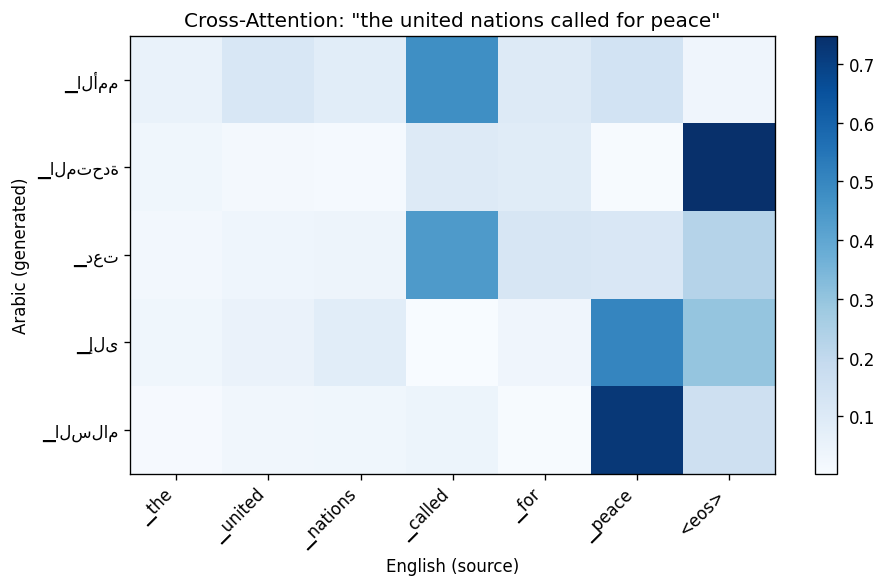

EN : the meeting was postponed until next week
AR : افتتحت الجلسة حتى الأسبوع المقبل .


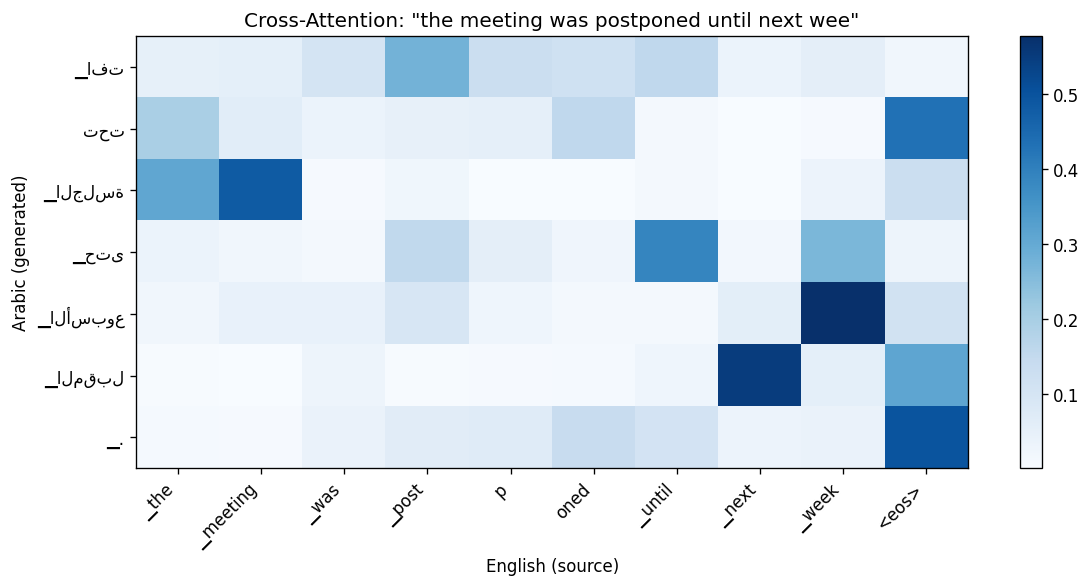

EN : students should study hard to succeed
AR : علماء الطلاب أن يدرسوا صعب تحقيقه


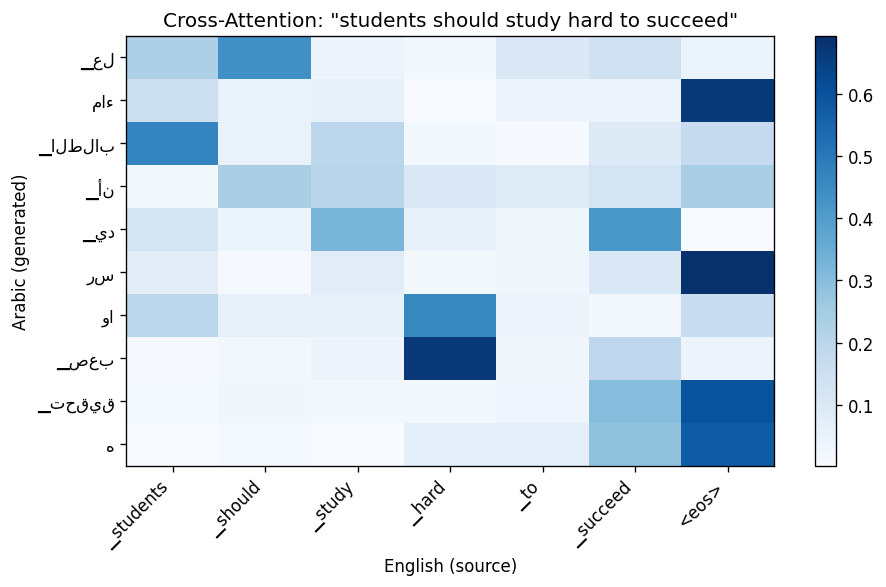

In [26]:
def plot_attention(en_text, ar_ids, attn_matrix, title='Cross-Attention'):
    en_tokens = sp_en.encode(en_text, out_type=str) + ['<eos>']
    ar_tokens = [sp_ar.id_to_piece(i) for i in ar_ids if i not in (PAD_IDX, SOS_IDX, EOS_IDX)]
    attn = attn_matrix[:len(ar_tokens), :len(en_tokens)]
    fig, ax = plt.subplots(figsize=(max(8, len(en_tokens)), max(5, len(ar_tokens)//2)))
    im = ax.imshow(attn, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(en_tokens))); ax.set_xticklabels(en_tokens, rotation=45, ha='right')
    ax.set_yticks(range(len(ar_tokens))); ax.set_yticklabels(ar_tokens)
    ax.set_xlabel('English (source)'); ax.set_ylabel('Arabic (generated)')
    ax.set_title(title); plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

demo_sentences = [
    'the united nations called for peace',
    'the meeting was postponed until next week',
    'students should study hard to succeed',
]
for sent in demo_sentences:
    src_ids = sp_en.encode(sent) + [EOS_IDX]
    ar_ids, attn_map = model.translate_greedy(torch.tensor(src_ids, dtype=torch.long))
    print(f'EN : {sent}')
    print(f'AR : {decode_ids(ar_ids)}')
    plot_attention(sent, ar_ids, attn_map, title=f'Cross-Attention: "{sent[:40]}"')


## Cell 16 — Save Final Checkpoint


In [27]:
torch.save({
    'model_state' : model.state_dict(),
    'history'     : history,
    'best_epoch'  : es.best_epoch,
    'best_val'    : es.best_loss,
    'bleu_greedy' : bleu_g.score,
    'bleu_beam5'  : bleu_b.score,
    'config' : dict(
        src_vocab=EN_VOCAB, tgt_vocab=AR_VOCAB,
        d_model=D_MODEL, n_layers=N_LAYERS,
        n_heads=N_HEADS, d_ff=D_FF, dropout=DROPOUT,
    )
}, FINAL_CKPT)

print('✅ All outputs saved to:', OUTPUT_DIR)
print('\nFiles saved:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(f'{OUTPUT_DIR}/{f}') / 1e6
    print(f'  {f:<35} {size:.1f} MB')

if ON_KAGGLE:
    print('\n📥 Download from the Output tab (right panel) in Kaggle.')
elif ON_COLAB:
    from google.colab import files
    files.download(FINAL_CKPT)

print(f'\n{"─"*55}')
print(f'Final Results')
print(f'  Best epoch     : {es.best_epoch}')
print(f'  Best val loss  : {es.best_loss:.4f}')
print(f'  Best val acc   : {max(history["acc"]):.1f}%')
print(f'  Greedy BLEU-4  : {bleu_g.score:.2f}')
print(f'  Beam-5 BLEU-4  : {bleu_b.score:.2f}')
print(f'  Training pairs : {len(train_pairs):,}')
print(f'  Model params   : {sum(p.numel() for p in model.parameters()):,}')
print("─"*55)


✅ All outputs saved to: /kaggle/working/nmt_checkpoints

Files saved:
  best_nmt.pt                         697.4 MB
  final_nmt.pt                        246.1 MB
  history.json                        0.0 MB
  spm_ar.model                        0.6 MB
  spm_ar.vocab                        0.3 MB
  spm_en.model                        0.4 MB
  spm_en.vocab                        0.1 MB
  training_curves.png                 0.2 MB

📥 Download from the Output tab (right panel) in Kaggle.

───────────────────────────────────────────────────────
Final Results
  Best epoch     : 21
  Best val loss  : 4.0334
  Best val acc   : 46.2%
  Greedy BLEU-4  : 12.68
  Beam-5 BLEU-4  : 12.57
  Training pairs : 300,000
  Model params   : 56,391,680
───────────────────────────────────────────────────────
